This is based on IU X-Ray dataset. Fintuning Blip.

In [ ]:
!git clone https://github.com/christiansafka/img2vec.git
!git clone https://github.com/nlpaueb/bio_image_caption.git

Cloning into 'img2vec'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 221 (delta 35), reused 28 (delta 23), pack-reused 155
Receiving objects: 100% (221/221), 597.70 KiB | 13.28 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Cloning into 'bio_image_caption'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 237 (delta 35), reused 37 (delta 25), pack-reused 184
Receiving objects: 100% (237/237), 93.52 MiB | 22.32 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [ ]:
!python bio_image_caption/SiVL19/get_iu_xray.py

--2024-06-17 00:41:07--  https://openi.nlm.nih.gov/imgs/collections/NLMCXR_png.tgz
Resolving openi.nlm.nih.gov (openi.nlm.nih.gov)... 130.14.65.157, 2607:f220:41e:7065::157
Connecting to openi.nlm.nih.gov (openi.nlm.nih.gov)|130.14.65.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1360814128 (1.3G) [application/x-gzip]
Saving to: ‘iu_xray/NLMCXR_png.tgz’

NLMCXR_png.tgz      100%[===================>]   1.27G  2.14MB/s    in 10m 7s  

2024-06-17 00:51:14 (2.14 MB/s) - ‘iu_xray/NLMCXR_png.tgz’ saved [1360814128/1360814128]

--2024-06-17 00:51:14--  https://openi.nlm.nih.gov/imgs/collections/NLMCXR_reports.tgz
Resolving openi.nlm.nih.gov (openi.nlm.nih.gov)... 130.14.65.157, 2607:f220:41e:7065::157
Connecting to openi.nlm.nih.gov (openi.nlm.nih.gov)|130.14.65.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1112632 (1.1M) [application/x-gzip]
Saving to: ‘iu_xray/NLMCXR_reports.tgz’

NLMCXR_reports.tgz  100%[===================>]

In [ ]:
import os
# Define the dataset folder and train and test files
dataset_path = "iu_xray/"
train_path = os.path.join(dataset_path, "train_images.tsv")
test_path = os.path.join(dataset_path, "test_images.tsv")

# Define the folder in which to save the results
!mkdir "iu_xray_results"
results_path = "iu_xray_results"

# Define the sub folder that contains the images
images_path = os.path.join(dataset_path, "iu_xray_images")

In [ ]:
import pandas as pd

# Load the train CSV file into a pandas DataFrame
train_df = pd.read_csv(train_path, delimiter='\t')

print("Number of rows:", train_df.shape[0])
print("Number of columns:", train_df.shape[1])


Number of rows: 6673
Number of columns: 2


In [ ]:
import pandas as pd

# Load the train CSV file into a pandas DataFrame
test_df = pd.read_csv(test_path, delimiter='\t')

print("Number of rows:", test_df.shape[0])
print("Number of columns:", test_df.shape[1])

Number of rows: 755
Number of columns: 2


In [ ]:
# Lagbe na
import pandas as pd

# Assuming 'data' is your DataFrame
randomized_data = train_df.sample(frac=1).reset_index(drop=True)


In [ ]:
# Lagbe na
# Define the sizes for each part
size_1 = 1000
size_2 = size_3 = 300
size_4 = len(randomized_data) - size_1 - size_2 - size_3

# Split the DataFrame into four parts
datasett = randomized_data.iloc[:size_1]
validition_data = randomized_data.iloc[size_1:size_1 + size_2]
testing_dataset = randomized_data.iloc[size_1 + size_2:size_1 + size_2 + size_3]
after = randomized_data.iloc[size_1 + size_2 + size_3:]

# Print the lengths of each part
print(f'Part 1 size: {len(datasett)}')
print(f'Part 2 size: {len(validition_data)}')
print(f'Part 3 size: {len(testing_dataset)}')
print(f'Part 4 size: {len(after)}')


Part 1 size: 1000
Part 2 size: 300
Part 3 size: 300
Part 4 size: 5073


In [ ]:
import pandas as pd
from PIL import Image
import os

# Assuming your DataFrame is named 'train_df' with columns 'image' and 'text'
dataset = []

# Iterate through each row in the DataFrame
for index, row in datasett.iterrows():
    image_path = os.path.join(images_path, row[0])
    image = Image.open(image_path)

    # Create a dictionary for each image and its text label
    data_item = {
        'image': image,
        'text': row[1]
    }

    # Append the dictionary to the dataset list
    dataset.append(data_item)


In [ ]:
import pandas as pd
from PIL import Image
import os

# Assuming your DataFrame is named 'train_df' with columns 'image' and 'text'
validition_dataset = []

# Iterate through each row in the DataFrame
for index, row in validition_data.iterrows():
    image_path = os.path.join(images_path, row[0])
    image = Image.open(image_path)

    # Create a dictionary for each image and its text label
    data_item = {
        'image': image,
        'text': row[1]
    }

    # Append the dictionary to the dataset list
    validition_dataset.append(data_item)


In [ ]:
import pandas as pd
from PIL import Image
import os

# Assuming your DataFrame is named 'train_df' with columns 'image' and 'text'
test_dataset = []
i_c = 0

# Iterate through each row in the DataFrame
for index, row in testing_dataset.iterrows():
    i_c += 1
    if i_c > 25:
      break
    image_path = os.path.join(images_path, row[0])
    image = Image.open(image_path)

    # Create a dictionary for each image and its text label
    data_item = {
        'image': image,
        'text': row[1]
    }

    # Append the dictionary to the dataset list
    test_dataset.append(data_item)


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
import torch
save_path = '/content/drive/MyDrive/blip-image-captioning-base_IU_X-Ray.pth'
model_tuned = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model_tuned.load_state_dict(torch.load(save_path))

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration

model_large = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

In [ ]:
def Caption(model, processor, image):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = processor(images=image,return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

In [ ]:
#@title Sentence Transformer

!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer,util
model_cos = SentenceTransformer('all-MiniLM-L6-v2')

def cosine_similarity(references, candidates):
  all_cos_socre = []
  for ref,can in zip(references,candidates):
    emb1 = model_cos.encode(ref)
    emb2 = model_cos.encode(can)
    cos_sim = util.cos_sim(emb1,emb2)
    all_cos_socre.append(max(cos_sim).item())

  return all_cos_socre;

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 5.7 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-m

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#@title bleu_scorer.py
import copy
import sys, math, re
from collections import defaultdict

def precook(s, n=4, out=False):
    """Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well."""
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return (len(words), counts)

def cook_refs(refs, eff=None, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.'''

    reflen = []
    maxcounts = {}
    for ref in refs:
        rl, counts = precook(ref, n)
        reflen.append(rl)
        for (ngram,count) in counts.items():
            maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    # Calculate effective reference sentence length.
    if eff == "shortest":
        reflen = min(reflen)
    elif eff == "average":
        reflen = float(sum(reflen))/len(reflen)

    ## lhuang: N.B.: leave reflen computaiton to the very end!!

    ## lhuang: N.B.: in case of "closest", keep a list of reflens!! (bad design)

    return (reflen, maxcounts)

def cook_test(test, ref_info, eff=None, n=4):
    reflen, refmaxcounts = ref_info
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.'''

    testlen, counts = precook(test, n, True)

    result = {}

    # Calculate effective reference sentence length.

    if eff == "closest":
        result["reflen"] = min((abs(l-testlen), l) for l in reflen)[1]
    else: ## i.e., "average" or "shortest" or None
        result["reflen"] = reflen

    result["testlen"] = testlen

    result["guess"] = [max(0,testlen-k+1) for k in range(1,n+1)]

    result['correct'] = [0]*n
    for (ngram, count) in counts.items():
        result["correct"][len(ngram)-1] += min(refmaxcounts.get(ngram,0), count)

    return result

class BleuScorer(object):
    """Bleu scorer.
    """

    __slots__ = "n", "crefs", "ctest", "_score", "_ratio", "_testlen", "_reflen", "special_reflen"
    # special_reflen is used in oracle (proportional effective ref len for a node).

    def copy(self):
        ''' copy the refs.'''
        new = BleuScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        new._score = None
        return new

    def __init__(self, test=None, refs=None, n=4, special_reflen=None):
        ''' singular instance '''

        self.n = n
        self.crefs = []
        self.ctest = []
        self.cook_append(test, refs)
        self.special_reflen = special_reflen

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                cooked_test = cook_test(test, self.crefs[-1])
                self.ctest.append(cooked_test) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

        self._score = None ## need to recompute

    def ratio(self, option=None):
        self.compute_score(option=option)
        return self._ratio

    def score_ratio(self, option=None):
        '''return (bleu, len_ratio) pair'''
        return (self.fscore(option=option), self.ratio(option=option))

    def score_ratio_str(self, option=None):
        return "%.4f (%.2f)" % self.score_ratio(option)

    def reflen(self, option=None):
        self.compute_score(option=option)
        return self._reflen

    def testlen(self, option=None):
        self.compute_score(option=option)
        return self._testlen

    def retest(self, new_test):
        if type(new_test) is str:
            new_test = [new_test]
        assert len(new_test) == len(self.crefs), new_test
        self.ctest = []
        for t, rs in zip(new_test, self.crefs):
            self.ctest.append(cook_test(t, rs))
        self._score = None

        return self

    def rescore(self, new_test):
        ''' replace test(s) with new test(s), and returns the new score.'''

        return self.retest(new_test).compute_score()

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new BleuScorer instances
            self.cook_append(other[0], other[1])
        else:
            assert self.compatible(other), "incompatible BLEUs."
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)
            self._score = None ## need to recompute

        return self

    def compatible(self, other):
        return isinstance(other, BleuScorer) and self.n == other.n

    def single_reflen(self, option="average"):
        return self._single_reflen(self.crefs[0][0], option)

    def _single_reflen(self, reflens, option=None, testlen=None):

        if option == "shortest":
            reflen = min(reflens)
        elif option == "average":
            reflen = float(sum(reflens))/len(reflens)
        elif option == "closest":
            reflen = min((abs(l-testlen), l) for l in reflens)[1]
        else:
            assert False, "unsupported reflen option %s" % option

        return reflen

    def recompute_score(self, option=None, verbose=0):
        self._score = None
        return self.compute_score(option, verbose)

    def compute_score(self, option=None, verbose=0):
        n = self.n
        small = 1e-9
        tiny = 1e-15 ## so that if guess is 0 still return 0
        bleu_list = [[] for _ in range(n)]

        if self._score is not None:
            return self._score

        if option is None:
            option = "average" if len(self.crefs) == 1 else "closest"

        self._testlen = 0
        self._reflen = 0
        totalcomps = {'testlen':0, 'reflen':0, 'guess':[0]*n, 'correct':[0]*n}

        # for each sentence
        for comps in self.ctest:
            testlen = comps['testlen']
            self._testlen += testlen

            if self.special_reflen is None: ## need computation
                reflen = self._single_reflen(comps['reflen'], option, testlen)
            else:
                reflen = self.special_reflen

            self._reflen += reflen

            for key in ['guess','correct']:
                for k in range(n):
                    totalcomps[key][k] += comps[key][k]

            # append per image bleu score
            bleu = 1.
            for k in range(n):
                bleu *= (float(comps['correct'][k]) + tiny) \
                        /(float(comps['guess'][k]) + small)
                bleu_list[k].append(bleu ** (1./(k+1)))
            ratio = (testlen + tiny) / (reflen + small) ## N.B.: avoid zero division
            if ratio < 1:
                for k in range(n):
                    bleu_list[k][-1] *= math.exp(1 - 1/ratio)

            # if verbose > 1:
            #     print (comps, reflen)

        totalcomps['reflen'] = self._reflen
        totalcomps['testlen'] = self._testlen

        bleus = []
        bleu = 1.
        for k in range(n):
            bleu *= float(totalcomps['correct'][k] + tiny) \
                    / (totalcomps['guess'][k] + small)
            bleus.append(bleu ** (1./(k+1)))
        ratio = (self._testlen + tiny) / (self._reflen + small) ## N.B.: avoid zero division
        if ratio < 1:
            for k in range(n):
                bleus[k] *= math.exp(1 - 1/ratio)

        # if verbose > 0:
        #     print (totalcomps)
        #     print( "ratio:", ratio)

        self._score = bleus
        return self._score, bleu_list

In [ ]:
#@title bleu.py

class Bleu:
    def __init__(self, n=4):
        # default compute Blue score up to 4
        self._n = n
        self._hypo_for_image = {}
        self.ref_for_image = {}

    def compute_score(self, gts, res):

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        bleu_scorer = BleuScorer(n=self._n)
        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) >= 1)

            bleu_scorer += (hypo[0], ref)

        #score, scores = bleu_scorer.compute_score(option='shortest')
        score, scores = bleu_scorer.compute_score(option='closest', verbose=1)
        #score, scores = bleu_scorer.compute_score(option='average', verbose=1)

        # return (bleu, bleu_info)
        return score, scores

    def method(self):
        return "Bleu"

In [ ]:
#@title cider_scorer.py

#!/usr/bin/env python
# Tsung-Yi Lin <tl483@cornell.edu>
# Ramakrishna Vedantam <vrama91@vt.edu>

import copy
from collections import defaultdict
import numpy as np
import pdb
import math

def cider_precook(s, n=4, out=False):
    """
    Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well.
    :param s: string : sentence to be converted into ngrams
    :param n: int    : number of ngrams for which representation is calculated
    :return: term frequency vector for occuring ngrams
    """
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cider_cook_refs(refs, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.
    :param refs: list of string : reference sentences for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (list of dict)
    '''
    return [cider_precook(ref, n) for ref in refs]

def cider_cook_test(test, n=4):
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.
    :param test: list of string : hypothesis sentence for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (dict)
    '''
    return cider_precook(test, n, True)

class CiderScorer(object):
    """CIDEr scorer.
    """

    def copy(self):
        ''' copy the refs.'''
        new = CiderScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        ''' singular instance '''
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cider_cook_refs(refs))
            if test is not None:
                self.ctest.append(cider_cook_test(test)) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new CiderScorer instances
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        '''
        Compute term frequency for reference data.
        This will be used to compute idf (inverse document frequency later)
        The term frequency is stored in the object
        :return: None
        '''
        for refs in self.crefs:
            # refs, k ref captions of one image
            for ngram in set([ngram for ref in refs for (ngram,count) in ref.items()]):
                self.document_frequency[ngram] += 1
            # maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    def compute_cider(self):
        def counts2vec(cnts):
            """
            Function maps counts of ngram to vector of tfidf weights.
            The function returns vec, an array of dictionary that store mapping of n-gram and tf-idf weights.
            The n-th entry of array denotes length of n-grams.
            :param cnts:
            :return: vec (array of dict), norm (array of float), length (int)
            """
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram,term_freq) in cnts.items():
                # give word count 1 if it doesn't appear in reference corpus
                df = np.log(max(1.0, self.document_frequency[ngram]))
                # ngram index
                n = len(ngram)-1
                # tf (term_freq) * idf (precomputed idf) for n-grams
                vec[n][ngram] = float(term_freq)*(self.ref_len - df)
                # compute norm for the vector.  the norm will be used for computing similarity
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            '''
            Compute the cosine similarity of two vectors.
            :param vec_hyp: array of dictionary for vector corresponding to hypothesis
            :param vec_ref: array of dictionary for vector corresponding to reference
            :param norm_hyp: array of float for vector corresponding to hypothesis
            :param norm_ref: array of float for vector corresponding to reference
            :param length_hyp: int containing length of hypothesis
            :param length_ref: int containing length of reference
            :return: array of score for each n-grams cosine similarity
            '''
            delta = float(length_hyp - length_ref)
            # measure consine similarity
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                # ngram
                for (ngram,count) in vec_hyp[n].items():
                    # vrama91 : added clipping
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n]*norm_ref[n])

                assert(not math.isnan(val[n]))
                # vrama91: added a length based gaussian penalty
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        # compute log reference length
        self.ref_len = np.log(float(len(self.crefs)))

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            # compute vector for test captions
            vec, norm, length = counts2vec(test)
            # compute vector for ref captions
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            # change by vrama91 - mean of ngram scores, instead of sum
            score_avg = np.mean(score)
            # divide by number of references
            score_avg /= len(refs)
            # multiply score by 10
            score_avg *= 10.0
            # append score of an image to the score list
            scores.append(score_avg)
        return scores

    def compute_score(self, option=None, verbose=0):
        # compute idf
        self.compute_doc_freq()
        # assert to check document frequency
        assert(len(self.ctest) >= max(self.document_frequency.values()))
        # compute cider score
        score = self.compute_cider()
        # debug
        # print score
        return np.mean(np.array(score)), np.array(score)

In [ ]:
#@title cider.py
# Filename: cider.py
#
# Description: Describes the class to compute the CIDEr (Consensus-Based Image Description Evaluation) Metric
#               by Vedantam, Zitnick, and Parikh (http://arxiv.org/abs/1411.5726)
#
# Creation Date: Sun Feb  8 14:16:54 2015
#
# Authors: Ramakrishna Vedantam <vrama91@vt.edu> and Tsung-Yi Lin <tl483@cornell.edu>

# from cider_scorer import CiderScorer
import pdb

class Cider:
    """
    Main Class to compute the CIDEr metric

    """
    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        # set cider to sum over 1 to 4-grams
        self._n = n
        # set the standard deviation parameter for gaussian penalty
        self._sigma = sigma

    def compute_score(self, gts, res):
        """
        Main function to compute CIDEr score
        :param  hypo_for_image (dict) : dictionary with key <image> and value <tokenized hypothesis / candidate sentence>
                ref_for_image (dict)  : dictionary with key <image> and value <tokenized reference sentence>
        :return: cider (float) : computed CIDEr score for the corpus
        """

        assert(gts.keys() == res.keys())
        imgIds = gts.keys()

        cider_scorer = CiderScorer(n=self._n, sigma=self._sigma)

        for id in imgIds:
            hypo = res[id]
            ref = gts[id]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)

            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score()

        return score, scores

    def method(self):
        return "CIDEr"

In [ ]:
!git clone https://github.com/tylin/coco-caption

Cloning into 'coco-caption'...
remote: Enumerating objects: 736, done.
remote: Total 736 (delta 0), reused 0 (delta 0), pack-reused 736
Receiving objects: 100% (736/736), 130.04 MiB | 32.85 MiB/s, done.
Resolving deltas: 100% (390/390), done.


In [ ]:
#@title get_the_scores Method
import sys

def get_the_scores(reference, candidate):
    reference = {'image_id': ['2sfdbs4646'], 'text': reference}
    candidate = {'image_id': ['2sfdbs4646'], 'text': candidate}

    # Calculate CIDEr score
    cider_calculator = Cider()
    cider_score, cider_scores = cider_calculator.compute_score(reference, candidate)

    # Calculate BLEU score
    bleu_calculator = Bleu()
    bleu_score, bleu_scores = bleu_calculator.compute_score(reference, candidate)

    # Append Rouge module path to sys.path
    sys.path.append('/content/coco-caption/pycocoevalcap/rouge')
    from rouge import Rouge
    rouge_calculator = Rouge()
    rouge_score, rouge_scores = rouge_calculator.compute_score(reference, candidate)

    # Return scores
    return {
        'CIDEr': {'score': cider_score, 'scores': cider_scores},
        'BLEU': {'score': bleu_score, 'scores': bleu_scores},
        'Rouge': {'score': rouge_score, 'scores': rouge_scores}
    }


In [ ]:
#@title print_the_scores(model, processor, dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------

def print_the_scores(model, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r,p = [],[]
  for id in testing_dataset:

    # print ("Image No: ", image_cnt)
    image = id['image']
    text = id['text']
    caption = Caption(model, processor, image)
    # print(f'{image_cnt}: {caption}')

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  #----------------Code for cosine score-----------------#
  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
len(test_dataset)

0

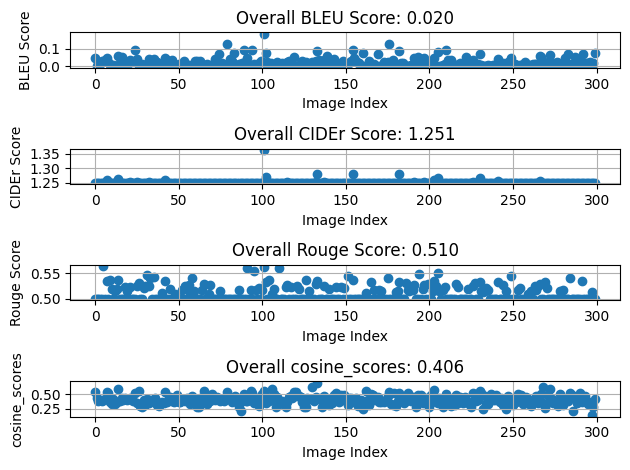

In [ ]:
# Base Model Scores
import torch
print_the_scores(model=model, processor=processor, testing_dataset=test_dataset)

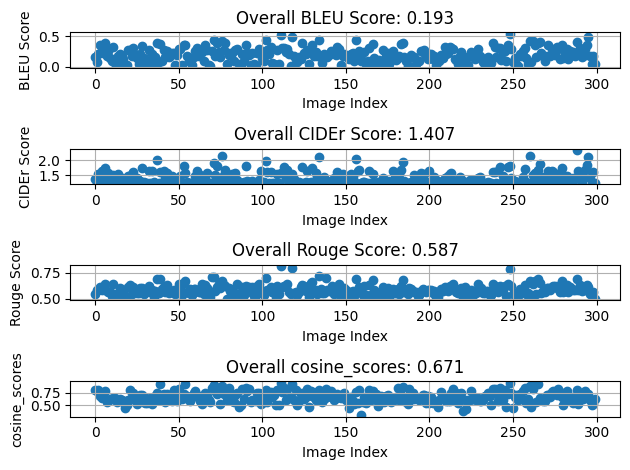

In [ ]:
# Base Fine-Tuned Model Scores
print_the_scores(model=model_tuned, processor=processor, testing_dataset=test_dataset)

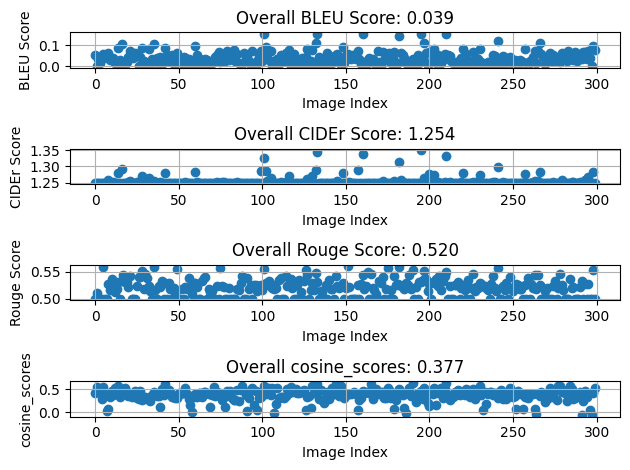

In [ ]:
# Large Model Scores
print_the_scores(model=model_large, processor=processor, testing_dataset=test_dataset)

In [ ]:
#@title sentence_by_proxy_logits (model, model_b, model_l, processor, image)
def sentence_by_proxy (model_base, model_tuned, model_target, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model_base.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
              logits_target + (logits_tuned - logits_base)
          )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r,p = [],[]
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy(model_base,model_tuned,model_target, processor = processor, image = image)
    # print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  #----------------Code for cosine score-----------------#
  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip-image-captioning-base")
device = "cuda" if torch.cuda.is_available() else "cpu"

NameError: name 'AutoTokenizer' is not defined

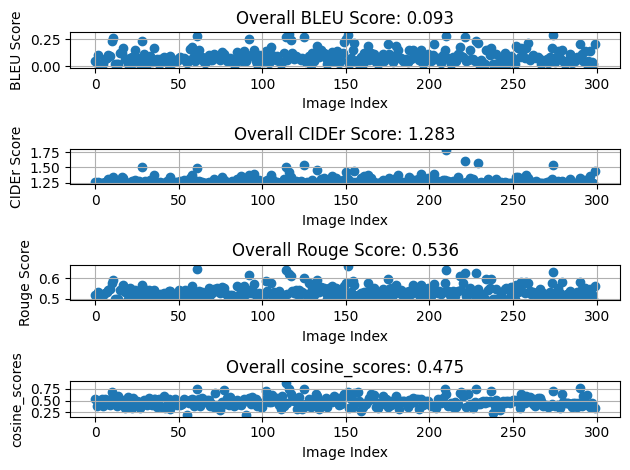

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration, AutoTokenizer
print_the_scores_of_proxy(model, model_tuned, model_large, processor,testing_dataset = test_dataset)

In [ ]:
#@title sentence_by_proxy_logits_min_max_normalization (model, model_b, model_l, processor, image)
import torch
from transformers import AutoTokenizer, AutoModel, AutoProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def min_max_normalize(logits):
    min_vals = logits.min(dim=-1, keepdim=True).values
    max_vals = logits.max(dim=-1, keepdim=True).values
    normalized_logits = (logits - min_vals) / (max_vals - min_vals + 1e-9)  # add epsilon to avoid division by zero
    # print(normalized_logits)
    return normalized_logits

def sentence_by_proxy_min_max (model_base, model_tuned, model_target, processor, image):
    inputs = processor(images=image, return_tensors="pt").to(device)

    decoder_input_ids = [model_base.decoder_input_ids]
    input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

    predicted_ids = []

    with torch.no_grad():
        for i in range(50):
            logits_base = model_base(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_tuned = model_tuned(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_target = model_target(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]

            # print(f'{logits_base} {i}')

            # Apply min-max normalization
            logits_base = min_max_normalize(logits_base)
            logits_tuned = min_max_normalize(logits_tuned)
            logits_target = min_max_normalize(logits_target)

            logits = logits_target + (logits_tuned - logits_base)
            predicted_id = logits.argmax(-1)
            predicted_ids.append(predicted_id.item())

            # Add predicted id to input_ids
            input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
            if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
                break

    sentence = tokenizer.decode(predicted_ids, skip_special_tokens=True)
    return sentence


In [ ]:
#@title print_the_scores_of_proxy_min_max(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------

def print_the_scores_of_proxy_min_max(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r, p = [], []
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_min_max(model_base,model_tuned,model_target, processor = processor, image = image)
    # print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)
    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

In [ ]:
model.cuda()
model_tuned.cuda()
model_large.cuda()

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-23): 24 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (projection): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (layer_norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1024,),

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration, AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip-image-captioning-base")
device = "cuda" if torch.cuda.is_available() else "cpu"

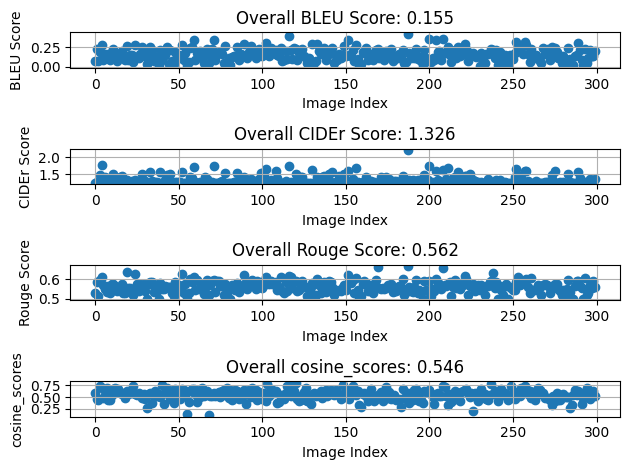

In [ ]:
print_the_scores_of_proxy_min_max(model, model_tuned, model_large, processor,testing_dataset = test_dataset)

In [ ]:
#@title sentence_by_proxy_z_score (model_base, model_tuned, model_target, processor, image):
import torch
from transformers import AutoTokenizer, AutoModel, AutoProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def z_score_normalize(logits):
    mean_vals = logits.mean(dim=-1, keepdim=True)
    std_vals = logits.std(dim=-1, keepdim=True)
    normalized_logits = (logits - mean_vals) / (std_vals + 1e-9)  # add epsilon to avoid division by zero
    return normalized_logits

def sentence_by_proxy_z_score (model_base, model_tuned, model_target, processor, image):
    inputs = processor(images=image, return_tensors="pt").to(device)

    decoder_input_ids = [model_base.decoder_input_ids]
    input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

    predicted_ids = []

    with torch.no_grad():
        for i in range(50):
            logits_base = model_base(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_tuned = model_tuned(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]
            logits_target = model_target(pixel_values=inputs.pixel_values, input_ids=input_ids).logits[:, i, :]

            # Apply z-score normalization
            logits_base = z_score_normalize(logits_base)
            logits_tuned = z_score_normalize(logits_tuned)
            logits_target = z_score_normalize(logits_target)

            logits = logits_target + (logits_tuned - logits_base)
            predicted_id = logits.argmax(-1)
            predicted_ids.append(predicted_id.item())

            # Add predicted id to input_ids
            input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
            if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
                break

    sentence = tokenizer.decode(predicted_ids, skip_special_tokens=True)
    return sentence



In [ ]:
#@title sentence_by_proxy_z_score(model_base,model_tuned,model_target, processor = processor, image = image)

def print_the_scores_of_proxy_z_score(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r, p = [], []
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_z_score(model_base,model_tuned,model_target, processor = processor, image = image)
    # print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)
    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

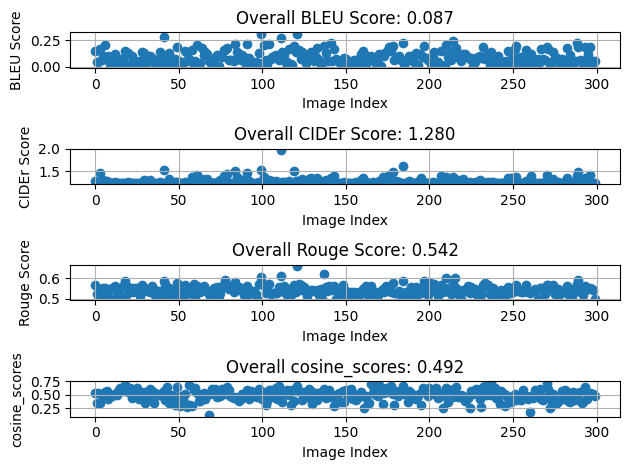

In [ ]:
print_the_scores_of_proxy_z_score(model, model_tuned, model_large, processor,testing_dataset = test_dataset)

In [ ]:
#@title sentence_by_proxy_logits_da(model, model_b, model_l, processor, image)
def sentence_by_proxy_da(model_base, model_tuned, model_target, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model_base.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(100):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
              logits_target + (2.0 *(logits_tuned - logits_base))
          )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy_da(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_da(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r,p = [],[]
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_da(model_base,model_tuned,model_target, processor = processor, image = image)
    print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)

    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  #----------------Code for cosine score-----------------#
  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all BLEU scores as a list
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

1: stable appearance. stable right basilar airspace opacities. stable xxxx opacification without focal consolidation. stable mild elevated right basilule. no definite pleural effusion seen. stable mild elevated right basilar airspace opacities. stable elevated right basilar airspace opacities, stable. stable elevated right lower lobe granulomatous atelectasis versus stable. stable right upper lung calcified granuloma. stable right lung calcified granuloma. stable
2: stable appearance. no focal consolidation. stable right basilar airspace opacification without definite pleural effusion. stable mild right basilar airspace opacification of the right lung base, which may be present in the right lung base, but no focal consolidation, pneumothorax or large pleural effusion is seen on the lateral view. no large pleural effusion is seen in the right upper lung base, large right lung, large pleural
3: stable appearance. stable right basilar airspace opacities. stable xxxx opacification without 

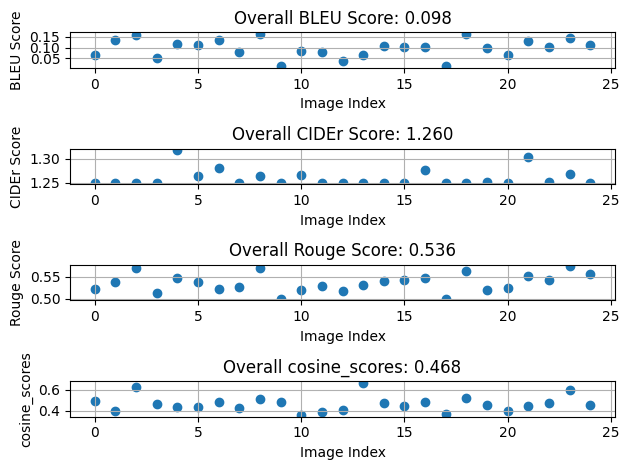

In [ ]:
 print_the_scores_of_proxy_da(model, model_tuned, model_large, processor,testing_dataset = test_dataset)

In [ ]:
#@title sentence_by_proxy_logits_Beta(model, model_b, model_l, processor, image)
def sentence_by_proxy_beta (model_base, model_tuned, model_target, processor, image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  decoder_input_ids = [model_base.decoder_input_ids]
  input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

  predicted_ids = []

  with torch.no_grad():
      for i in range(50):

          # input_ids_tuned.input_ids = inputs.input_ids
          # input_ids_target.input_ids = inputs.input_ids

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
             (0.5 + 1.0) * logits_target +(0.5 * (logits_tuned - logits_base))
          )
          # logits = (
          #    logits_target +((0.5 + 1.0) *  logits_tuned - 0.5 * logits_base)
          # )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break
  sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
  return sentence


In [ ]:
#@title print_the_scores_of_proxy_beta(model, model_b, model_l, processor, testing_dataset)
# ----------------------------Calculate the real Bleu score--------------------------------------
def print_the_scores_of_proxy_beta(model_base, model_tuned, model_target, processor, testing_dataset):
  import matplotlib.pyplot as plt
  image_cidar_scores = []
  image_bleu_scores = []
  image_rouge_scores = []
  image_cnt = 1
  r,p = [],[]
  for id in testing_dataset:
    image = id['image']
    text = id['text']
    caption = sentence_by_proxy_beta(model_base,model_tuned,model_target, processor = processor, image = image)
    # print(f'{image_cnt}: {caption}')
    references, predictions = [], []
    references.append(text)
    predictions.append(caption)
    r.append(text)
    p.append(caption)


    # results = bleu.compute(predictions=predictions, references=references, max_order = 2)
    result = get_the_scores(references, predictions)

    image_cidar_scores.append(result['CIDEr']['score'])
    image_bleu_scores.append(result['BLEU']['score'][0])
    image_rouge_scores.append(result['Rouge']['score'])

    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  final_cidar_score = sum(image_cidar_scores) / len(image_bleu_scores)
  final_rouge_score = sum(image_rouge_scores) / len(image_bleu_scores)

  plt.subplot(4, 1, 1)
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  # plt.title("BLEU Scores vs. Image Index")
  plt.title("Overall BLEU Score: %.3f" % final_bleu_score)
  plt.grid(True)

  plt.subplot(4, 1, 2)
  cidar_scores = list(image_cidar_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(cidar_scores)), cidar_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("CIDEr Score")
  plt.title("Overall CIDEr Score: %.3f" % final_cidar_score)
  plt.grid(True)

  # ---------------Code for Rouge plot------------------ #
  plt.subplot(4, 1, 3)
  rouge_scores = list(image_rouge_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(rouge_scores)), rouge_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("Rouge Score")
  plt.title("Overall Rouge Score: %.3f" % final_rouge_score)
  plt.grid(True)

  #----------------Code for cosine score-----------------#
  plt.subplot(4, 1, 4)
  cosine_scores =   cosine_similarity(r, p) # Extract all cosine scores as a list
  print(len(cosine_scores))
  final_cosine_score = sum(cosine_scores) / len(cosine_scores)
  plt.scatter(range(len(cosine_scores)), cosine_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("cosine_scores")
  plt.title("Overall cosine_scores: %.3f" % final_cosine_score)
  plt.grid(True)

  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Display the plot
  plt.show()

25


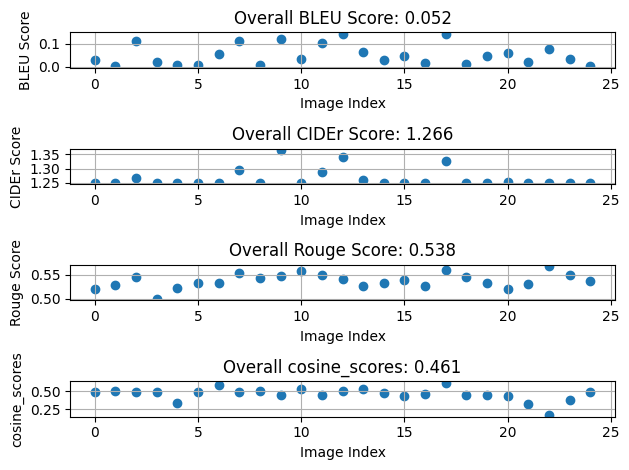

In [ ]:
print_the_scores_of_proxy_beta(model, model_tuned, model_large, processor,testing_dataset = test_dataset)

## **Eikhane er porer gulo te tomar ar kaj nai. tumi eitar upore tomar code likhe kaj koro **

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main
!pip install -q datasets

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-2c8afn15
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-2c8afn15
  Resolved https://github.com/huggingface/transformers.git to commit eed9ed679878ada2f6d2eefccdbda368cabc88b1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-4.42.0.dev0-py3-none-any.whl size=9161474 sha256=6e78ba9d83141a6bb791e6a91413845447befd15c5a3c116975ce00cebe203bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-ftov77ww/wheels/cf/59/82/6492402e887a68975030bf8c06532260abc16abb7ccd8127cc
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.2
    Uninstalling transformers-4.41.2:
      Successfully uninstalled transformers-4.41.2
     ━━━━

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [ ]:
train_dataset = ImageCaptioningDataset(dataset, processor_fine)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=1)
val_dataset = ImageCaptioningDataset(validition_dataset, processor_fine)
val_dataloader = DataLoader(val_dataset, shuffle=True, batch_size=1)

In [ ]:
import torch
from statistics import mean
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoConfig
from datasets import load_metric, Dataset, DatasetDict
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # Optional for progress bar

# ... (other imports and dataset loading as before)

# Load the BLIP model for conditional generation (replace if needed)

# Optimizer (adjust learning rate or other hyperparameters if needed)
optimizer = torch.optim.AdamW(model_fine.parameters(), lr=6e-6)

# Device selection (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_fine.to(device)

# Training hyperparameters
num_epochs = 1 # ------------------------------Adjust as needed ------------------------------- #
patience = 2  # -------------Number of epochs to wait for improvement (for early stopping)-------------------- #
best_val_loss = float("inf")  # Initialize best validation loss
current_patience = 0  # Initialize current_patience outside the loop

def train(train_dataloader, val_dataloader):
  model_fine.train()
  train_loss = 0.0

  for batch in tqdm(train_dataloader, desc="Training"):  # Optional progress bar
    batch = {k: v.to(device) for k, v in batch.items()}

    # Forward pass
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = model_fine(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)
    loss = outputs.loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss += loss.item()

  # Validation after each epoch
  val_loss = evaluate(val_dataloader)
  print(f'Epoch {epoch} - Train Loss: {train_loss / len(train_dataloader):.4f}, Val Loss: {val_loss:.4f}')

  # Early stopping (optional)
  global best_val_loss
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    current_patience = 0  # Reset patience counter if loss improves
  else:
    current_patience = current_patience + 1
  if current_patience >= patience:
    print(f'Early stopping at epoch {epoch} due to no improvement in validation loss')
    return  # Exit training loop if patience is exhausted

def evaluate(dataloader):
  model_fine.eval()
  eval_loss = 0.0

  with torch.no_grad():
    for batch in dataloader:
      batch = {k: v.to(device) for k, v in batch.items()}
      input_ids = batch.pop("input_ids").to(device)
      pixel_values = batch.pop("pixel_values").to(device)

      outputs = model_fine(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)


      loss = outputs.loss

      eval_loss += loss.item()

  return eval_loss / len(dataloader)


for epoch in range(num_epochs):
  train(train_dataloader, val_dataloader)


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 - Train Loss: 2.7237, Val Loss: 0.4223


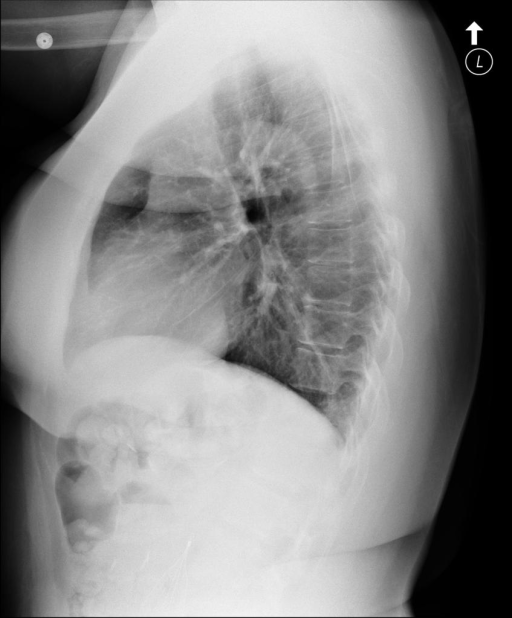

In [ ]:
# image_filename = train_df.iloc[0]['image']
# print(train_df.iloc[5, 0])
iamge_val = train_df.iloc[3, 0];
image_val = os.path.join( images_path, iamge_val)
from PIL import Image

# Open the image
image = Image.open(image_val)

# Now you can work with the image, for example, display it
image

In [ ]:
iamge_caption = train_df.iloc[1500, 1];
iamge_caption

'Emphysema without acute disease. The heart is normal in size. The mediastinum is unremarkable. The lungs are grossly clear. Underlying emphysematous changes are noted.'

In [ ]:
import pandas as pd
from PIL import Image
import os

# Assuming your DataFrame is named 'train_df' with columns 'image' and 'text'
dataset = []

# Iterate through each row in the DataFrame
for index, row in train_df.iterrows():
    image_path = os.path.join(images_path, row[0])
    image = Image.open(image_path)

    # Create a dictionary for each image and its text label
    data_item = {
        'image': image,
        'text': row[1]
    }

    # Append the dictionary to the dataset list
    dataset.append(data_item)


# dataset = {}

# for idx, row in train_df.iterrows():
#     image_val = row[0]  # Replace "image_column" with the actual column name containing image paths
#     text = row[1]  # Replace "text_column" with the actual column name containing text

#     image_val = os.path.join( images_path, iamge_val)
#     image = Image.open(image_val)

#     dataset[idx] = {"image": image, "text": text}

In [ ]:
dataset[4000]['image']

NameError: name 'dataset' is not defined

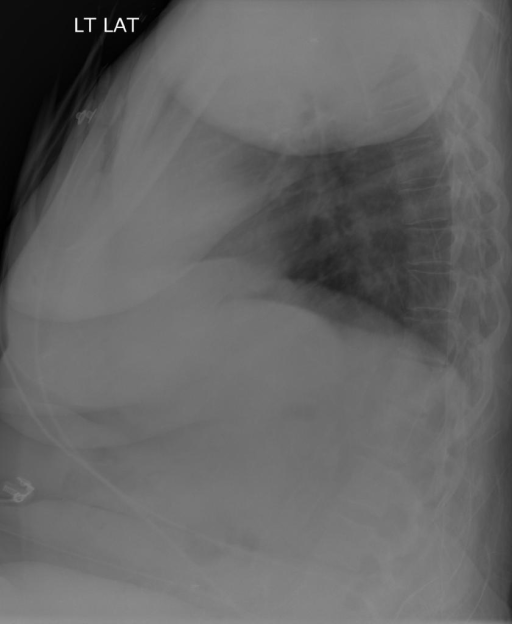

In [ ]:
dataset[1510]['image']

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-ny0n9x09
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-ny0n9x09
  Resolved https://github.com/huggingface/transformers.git to commit 77b59dce9fb804c72e3e9f3eaa01d53a905e6ada
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-4.41.0.dev0-py3-none-any.whl size=9044253 sha256=1ccb0dcffc2d2c9f0681422f90972d0828dab230fbc93197e5a7e140d13be468
  Stored in directory: /tmp/pip-ephem-wheel-cache-9_f3voke/wheels/cf/59/82/6492402e887a68975030bf8c06532260abc16abb7ccd8127cc
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 4.40.0
    Uninstalling transformers-4.40.0:
      Successfully uninstalled transformers-4.40.0


In [ ]:
# !pip install -q datasets

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_tuned = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [ ]:
dataset1 = []
i = 0
for d in dataset:
  dataset1.append(d)
  i = i + 1
  if(i==100):
    break

In [ ]:
train_dataset = ImageCaptioningDataset(dataset1, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=2)

In [ ]:
len(train_dataloader)

50

In [ ]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
image_no = 1
for epoch in range(30):
  print("Epoch:", epoch)
  image_no = 1
  for idx, batch in enumerate(train_dataloader):
    print (image_no)
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)

    loss = outputs.loss

    print("Loss:", loss.item())

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()
    image_no = image_no + 1

In [ ]:
from google.colab import drive
import torch

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Define the path where you want to save the model in your Google Drive
save_path = '/content/drive/MyDrive/blip-image-captioning-base_By_iu_xray[1000]epoch1.pth'
# Assuming you have already initialized and trained your model and named it 'model'
# Save the model to the specified path
torch.save(model_fine.state_dict(), save_path)

In [ ]:
save_path = '/content/drive/MyDrive/blip-image-captioning-base_By_iu_xray[1000]epoch1.pth'
model_tuned = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model_tuned.load_state_dict(torch.load(save_path))

NameError: name 'BlipForConditionalGeneration' is not defined

In [ ]:
# image_filename = train_df.iloc[0]['image']
# print(train_df.iloc[5, 0])
iamge_val = train_df.iloc[6, 0];
image_val = os.path.join( images_path, iamge_val)
from PIL import Image

# Open the image
image = Image.open(image_val)

# Now you can work with the image, for example, display it
image

NameError: name 'train_df' is not defined

Saving image (1).jpg to image (1).jpg


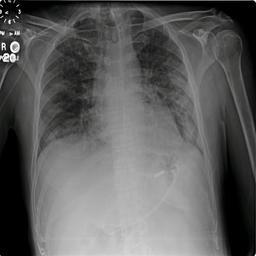

In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read the uploaded image file
import io
from PIL import Image

image = Image.open(io.BytesIO(uploaded[file_name]))

# Display the uploaded image
image

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model_tuned.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model_tuned.generate(pixel_values=pixel_values, max_length=200)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

no acute cardiopulmonary abnormality. no focal airspace disease, pneumothorax, or pneumothorax, pneumothorax, or pneumothorax, or pleural effusion, or pneumothorax, or pneumothorax, or pneumothorax, or pneumothorax, or pneumothorax, or pneumothorax, or pneumothorax


In [ ]:
model.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

a radiograph of a chest with a radiograph of the chest


In [ ]:
# Calculate the number of images to print
num_images = min(len(dataset), 100)

# Iterate over each image and print the text
for i in range(num_images):
    # Get text from dataset
    text = dataset[i]['text']

    # Print text
    print(text)


In [ ]:
print(model)